In [1]:
import pandas as pd
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [16]:
input_path = Path("ARR_MARCH") / "Output" / "summaries" / "Ablation" / "CC_VE_LLMLEVEL"
#input_path = Path(r"C:\Users\kpoth\Downloads\CCT\GitHub\cct-python\ARR_MARCH\Output\summaries\Ablation\CC_VE_LLMLEVEL")

In [3]:
domain_files = {
    "SCTOM": [
        "CC_VE_LLMLevel_SCTOM_I.csv", 
        "CC_VE_LLMLevel_SCTOM_II.csv", 
        "CC_VE_LLMLevel_SCTOM_III.csv"
    ],
    "SVNS": [
        "CC_VE_LLMLevel_SVNS_I.csv", 
        "CC_VE_LLMLevel_SVNS_II.csv", 
        "CC_VE_LLMLevel_SVNS_III.csv"
    ],
    "PIPP": [
        "CC_VE_LLMLevel_PIPP_I.csv", 
        "CC_VE_LLMLevel_PIPP_II.csv"
    ],
    "PCPR": [
        "CC_VE_LLMLevel_PCPR_I.csv", 
        "CC_VE_LLMLevel_PCPR_II.csv"
    ]
}

In [4]:
num_cols = ['variance_explained', 'eig_ratio', 'comp_raw_mean', 'comp_q99_mean', 'pct_agreement_consensus']

In [5]:
for domain_name, file_list in domain_files.items():
    print(f"Processing {domain_name}...")
    
    # Read and concatenate all sub-files for the current domain
    df_list = [pd.read_csv(f'{input_path}/{f}') for f in file_list]
    combined_df = pd.concat(df_list, ignore_index=True)
    
    # Ensure our target columns are perfectly numeric
    for col in num_cols:
        if col in combined_df.columns:
            combined_df[col] = pd.to_numeric(combined_df[col], errors='coerce')
    
    # Group by the identifiers and average, keeping NA prompts intact for humans
    aggregated_df = combined_df.groupby(
        ['country', 'group', 'llm_model'], dropna=False
    )[num_cols].mean().reset_index()
    
    # Set the overarching domain name
    aggregated_df['domain'] = domain_name
    
    # Save the finalized, aggregated CSV for this domain
    output_filename = f"{input_path}/CC_VE_LLMLevel_{domain_name}.csv"
    aggregated_df.to_csv(output_filename, index=False)
    
    print(f"Saved aggregated file: {output_filename}\n")

Processing SCTOM...
Saved aggregated file: C:\Users\kpoth\Downloads\CCT\GitHub\cct-python\ARR_MARCH\Output\summaries\Ablation\CC_VE_LLMLEVEL/CC_VE_LLMLevel_SCTOM.csv

Processing SVNS...
Saved aggregated file: C:\Users\kpoth\Downloads\CCT\GitHub\cct-python\ARR_MARCH\Output\summaries\Ablation\CC_VE_LLMLEVEL/CC_VE_LLMLevel_SVNS.csv

Processing PIPP...
Saved aggregated file: C:\Users\kpoth\Downloads\CCT\GitHub\cct-python\ARR_MARCH\Output\summaries\Ablation\CC_VE_LLMLEVEL/CC_VE_LLMLevel_PIPP.csv

Processing PCPR...
Saved aggregated file: C:\Users\kpoth\Downloads\CCT\GitHub\cct-python\ARR_MARCH\Output\summaries\Ablation\CC_VE_LLMLEVEL/CC_VE_LLMLevel_PCPR.csv



In [6]:
aggregated_files = [
    "CC_VE_LLMLevel_SCTOM.csv",
    "CC_VE_LLMLevel_SVNS.csv",
    "CC_VE_LLMLevel_PIPP.csv",
    "CC_VE_LLMLevel_PCPR.csv"
]

single_files = [
    "CC_VE_LLMLevel_POST.csv", 
    "CC_VE_LLMLevel_POS.csv", 
    "CC_VE_LLMLevel_POC.csv", 
    "CC_VE_LLMLevel_POM.csv", 
    "CC_VE_LLMLevel_EV.csv", 
    "CC_VE_LLMLevel_EVN.csv", 
    "CC_VE_LLMLevel_RV.csv", 
    "CC_VE_LLMLevel_HWB.csv"
]

In [7]:
all_dataframes = []

for file in aggregated_files:
    df = pd.read_csv(f'{input_path}/{file}')
    all_dataframes.append(df)
    print(f"Loaded {file}")

Loaded CC_VE_LLMLevel_SCTOM.csv
Loaded CC_VE_LLMLevel_SVNS.csv
Loaded CC_VE_LLMLevel_PIPP.csv
Loaded CC_VE_LLMLevel_PCPR.csv


In [8]:
for file in single_files:
    df = pd.read_csv(f'{input_path}/{file}')
    domain_name = file.replace("CC_VE_LLMLevel_", "").replace(".csv", "")
    
    df['domain'] = domain_name
    all_dataframes.append(df)
    print(f"Loaded {file} (Domain assigned: {domain_name})")

Loaded CC_VE_LLMLevel_POST.csv (Domain assigned: POST)
Loaded CC_VE_LLMLevel_POS.csv (Domain assigned: POS)
Loaded CC_VE_LLMLevel_POC.csv (Domain assigned: POC)
Loaded CC_VE_LLMLevel_POM.csv (Domain assigned: POM)
Loaded CC_VE_LLMLevel_EV.csv (Domain assigned: EV)
Loaded CC_VE_LLMLevel_EVN.csv (Domain assigned: EVN)
Loaded CC_VE_LLMLevel_RV.csv (Domain assigned: RV)
Loaded CC_VE_LLMLevel_HWB.csv (Domain assigned: HWB)


In [9]:
final_master_df = pd.concat(all_dataframes, ignore_index=True)

In [10]:
single_culture_countries = ['Armenia', 'Japan', 'Greece', 'Germany', 'Netherlands'] 
multi_culture_countries = ['Colombia', 'Mexico', 'Peru', 'United_States', 'Malaysia']

In [11]:
def assign_culture_type(country):
    if country in single_culture_countries:
        return 'Single-Culture'
    elif country in multi_culture_countries:
        return 'Multi-Culture'
    else:
        return 'Unknown'

final_master_df['culture_type'] = final_master_df['country'].apply(assign_culture_type)

In [12]:
human_df = final_master_df[final_master_df['group'] == 'human'][['domain', 'country', 'culture_type', 'variance_explained']].copy()
human_df = human_df.rename(columns={'variance_explained': 'human_variance'})

llm_df = final_master_df[final_master_df['group'] == 'llm'][['domain', 'country', 'culture_type', 'llm_model', 'variance_explained', 'pct_agreement_consensus']].copy()
llm_df = llm_df.rename(columns={'variance_explained': 'llm_variance'})
llm_df['pct_agreement_consensus'] = pd.to_numeric(llm_df['pct_agreement_consensus'], errors='coerce')

# Merge and calculate
plot_data = pd.merge(llm_df, human_df, on=['domain', 'country', 'culture_type'], how='left')
plot_data['delta_ve'] = plot_data['llm_variance'] - plot_data['human_variance']
plot_data['cc_score'] = plot_data['pct_agreement_consensus'] / 100.0

In [13]:
plot_data = plot_data.dropna(subset=['delta_ve', 'cc_score'])

In [14]:
plot_data

,domain,country,culture_type,llm_model,llm_variance,pct_agreement_consensus,human_variance,delta_ve,cc_score
0,SCTOM,Armenia,Single-Culture,GPT-OSS_120B,0.749644,51.010101,0.538650,0.210994,0.510101
1,SCTOM,Armenia,Single-Culture,GPT_4O,0.812973,59.090909,0.538650,0.274324,0.590909
2,SCTOM,Armenia,Single-Culture,LLAMA3_1_70B,0.648313,37.037037,0.538650,0.109664,0.370370
3,SCTOM,Armenia,Single-Culture,LLAMA3_70B,0.726889,45.622896,0.538650,0.188239,0.456229
4,SCTOM,Armenia,Single-Culture,PHI3_INSTRUCT,0.743209,34.511785,0.538650,0.204559,0.345118
...,...,...,...,...,...,...,...,...,...
1195,HWB,United_States,Multi-Culture,QWEN_7B,0.696444,0.000000,0.624164,0.072280,0.000000
1196,HWB,United_States,Multi-Culture,QWEN2_5VL_32B,0.847651,0.000000,0.624164,0.223487,0.000000
1197,HWB,United_States,Multi-Culture,QWEN2_5VL_72B,0.893542,60.000000,0.624164,0.269378,0.600000
1198,HWB,United_States,Multi-Culture,QWEN2_5VL_7B,0.763039,0.000000,0.624164,0.138876,0.000000


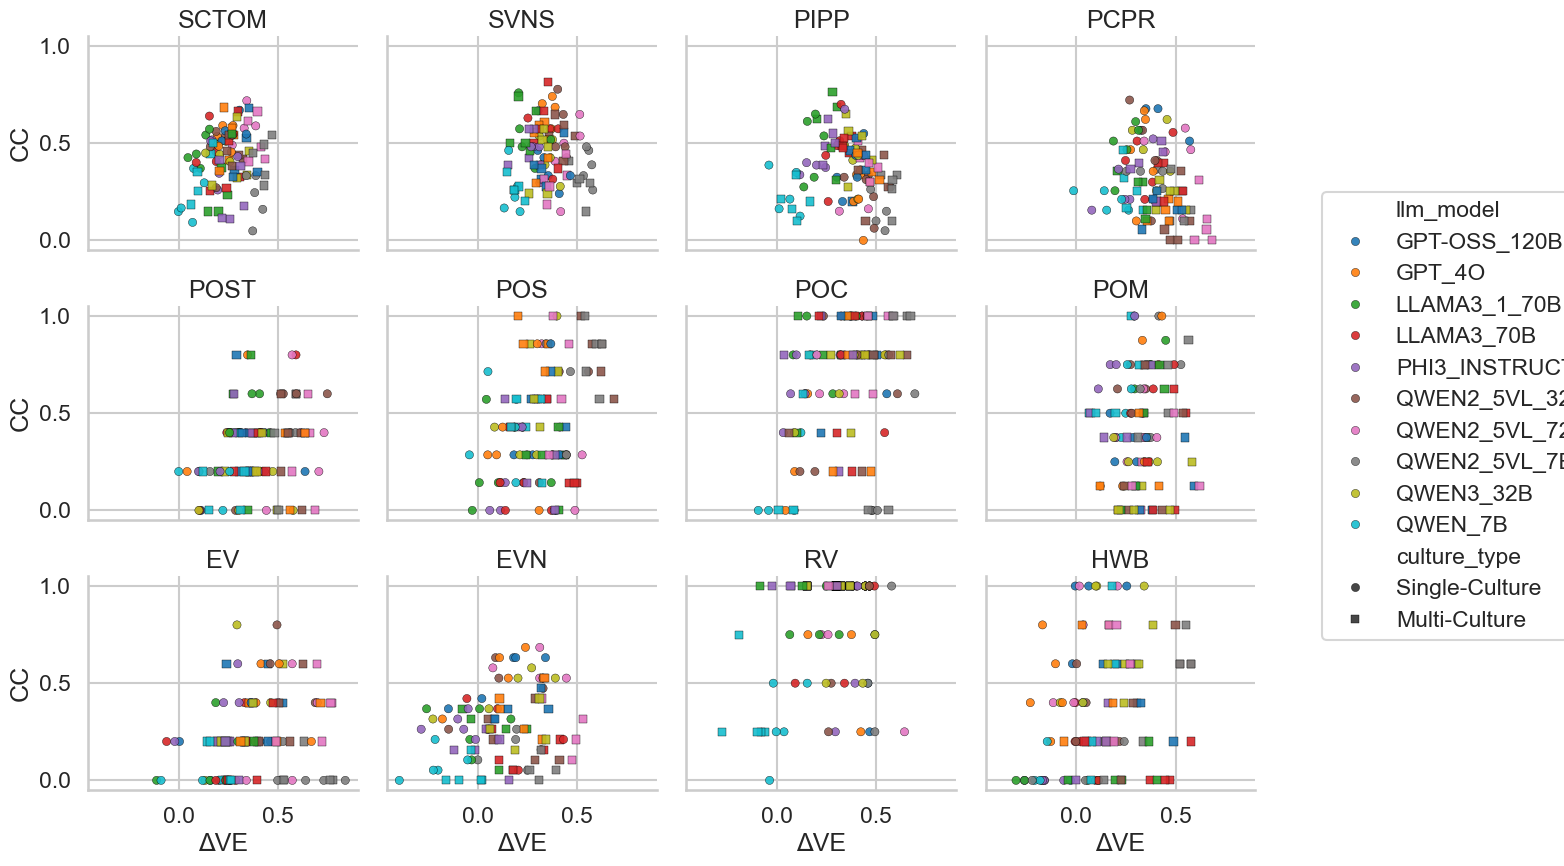

In [15]:
sns.set_theme(style="whitegrid", context="talk")
palette = sns.color_palette("tab10", n_colors=plot_data["llm_model"].nunique())

g = sns.relplot(
    data=plot_data,
    col="domain",
    col_wrap=4,
    x="delta_ve",              
    y="cc_score",         
    hue="llm_model",
    style="culture_type",
    markers={"Single-Culture": "o", "Multi-Culture": "s"},  
    kind="scatter",
    palette=palette,
    alpha=0.9,        
    s=35,             
    edgecolor="black",
    linewidth=0.3,
    height=3.0,
    facet_kws=dict(sharex=True, sharey=True),
    legend="full"
)

g.set_axis_labels("ΔVE", "CC")
g.set_titles("{col_name}")
g.figure.subplots_adjust(right=0.88)

#for ax in g.axes.flat:
#    ax.grid(True, which="major", axis="both")

#plt.tight_layout()

if g._legend is not None:
    g._legend.set_bbox_to_anchor((0.89, 0.5))  
    g._legend.set_loc("center left")
    g._legend.set_frame_on(True)

plt.show()

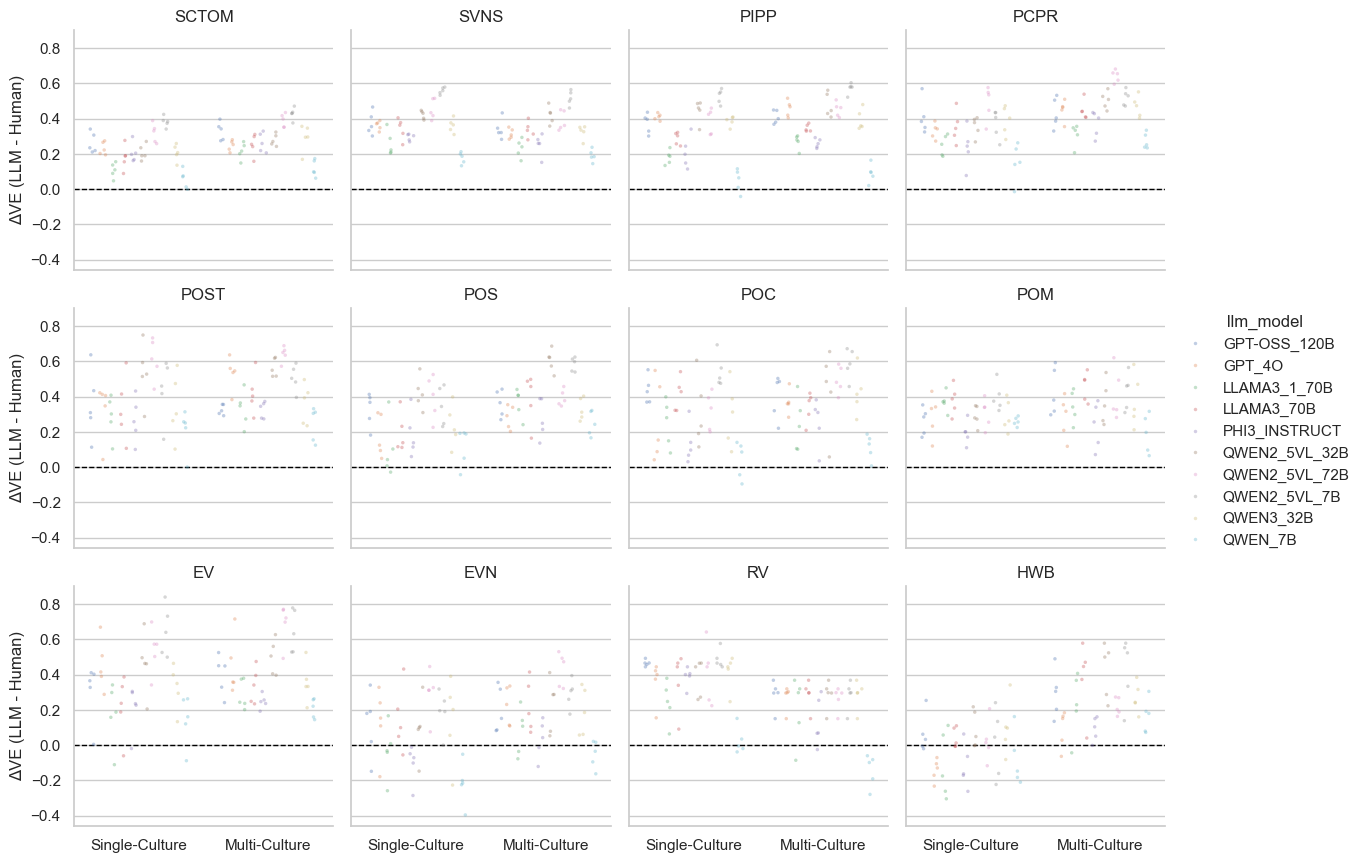

In [23]:
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=plot_data,
    col="domain",
    col_wrap=4,
    x="culture_type",
    y="delta_ve",
    hue="llm_model",
    kind="strip",
    dodge=True,     
    jitter=0.25,
    alpha=0.35,
    size=2.5,
    height=3.0,
    sharey=True
)

for ax in g.axes.flat:
    ax.axhline(0, ls="--", c="black", lw=1)

g.set_axis_labels("", "ΔVE (LLM - Human)")
g.set_titles("{col_name}")
plt.show()

### We can use this to aggregate across LLM families like GPT, Llama and Qwen (More than 4 datapoints make this plot harder to understand, but it is easier to see the spread across single and multi group clearly with less datapoints)

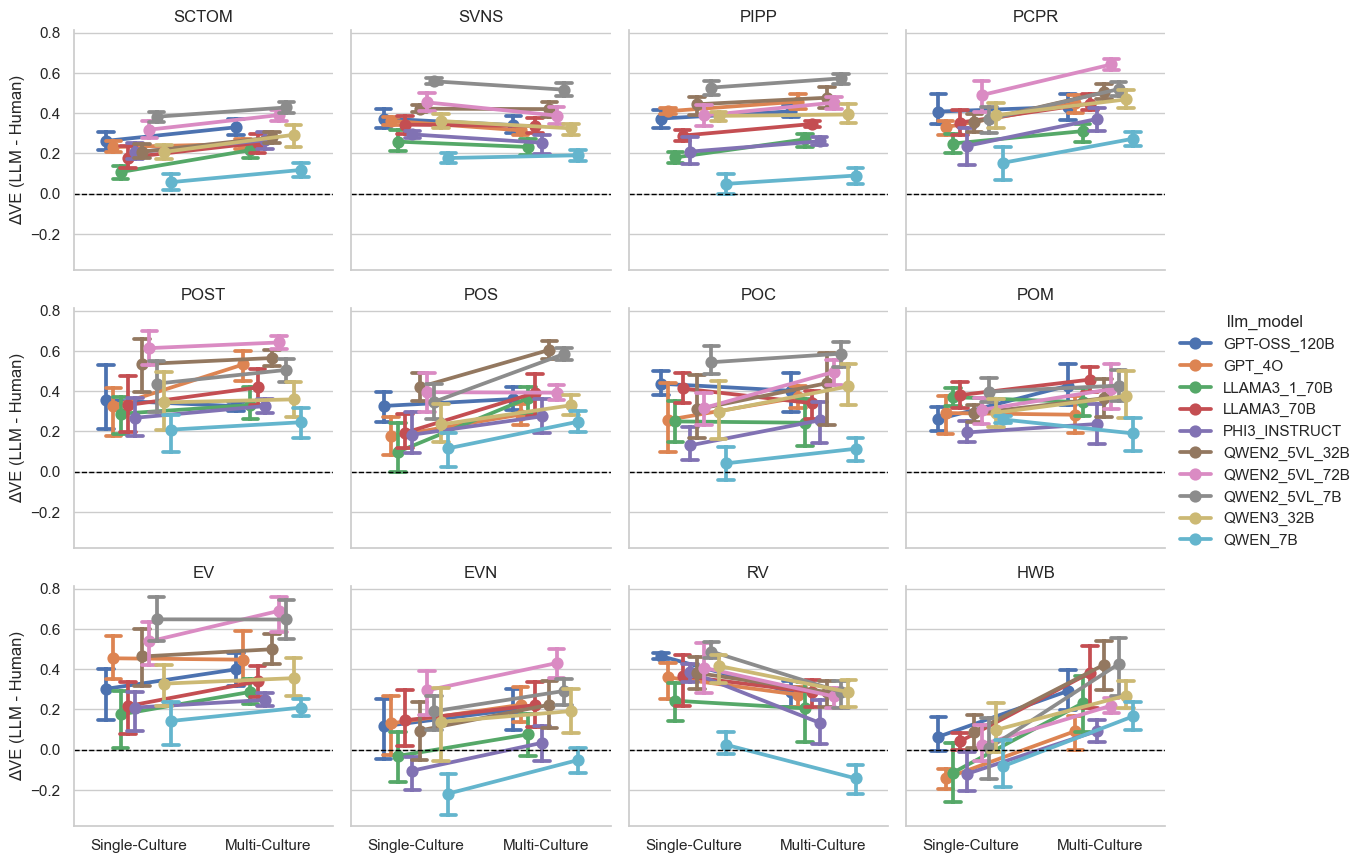

In [24]:
sns.set_theme(style="whitegrid")

g = sns.catplot(
    data=plot_data,
    col="domain",
    col_wrap=4,
    x="culture_type",
    y="delta_ve",
    hue="llm_model",
    kind="point",
    dodge=0.5,
    errorbar=("ci", 95),
    capsize=0.12,
    height=3.0,
    sharey=True
)

for ax in g.axes.flat:
    ax.axhline(0, ls="--", c="black", lw=1)

g.set_axis_labels("", "ΔVE (LLM - Human)")
g.set_titles("{col_name}")
plt.show()